In [27]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
df = pd.read_csv('Customer Churn.csv')
Y = df['Customer Value']
X = df[['Seconds of Use', 'Frequency of SMS', 'Call  Failure', 'Complains', 'Subscription  Length']]
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Customer Value   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                 1.508e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:19:42   Log-Likelihood:                -19082.
No. Observations:                3150   AIC:                         3.818e+04
Df Residuals:                    3144   BIC:                         3.821e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -9.6234 

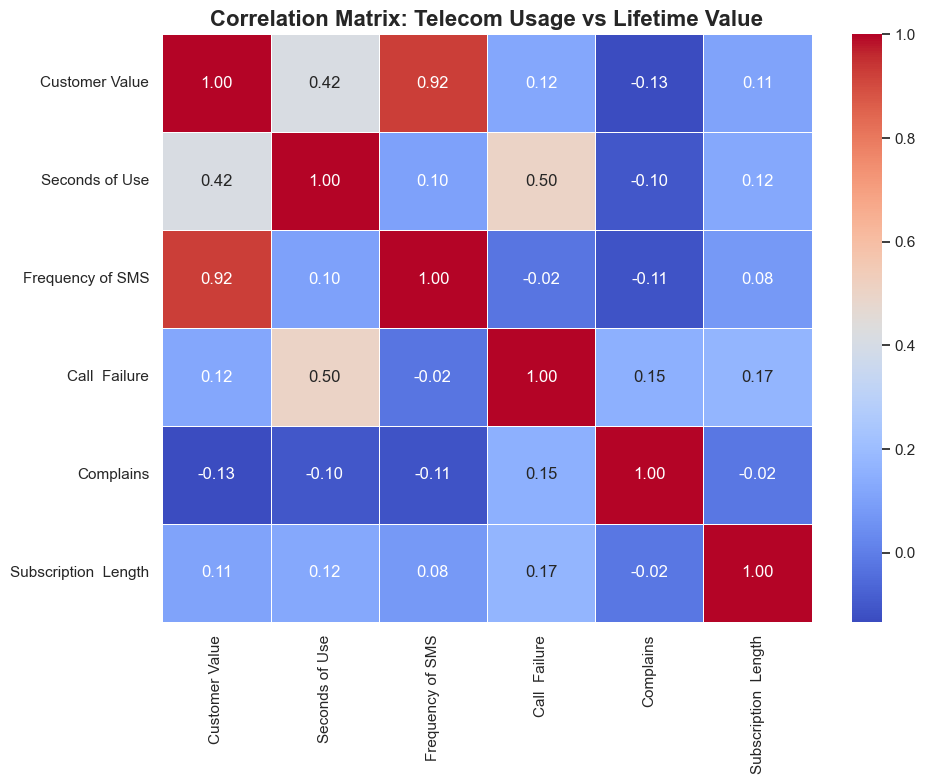

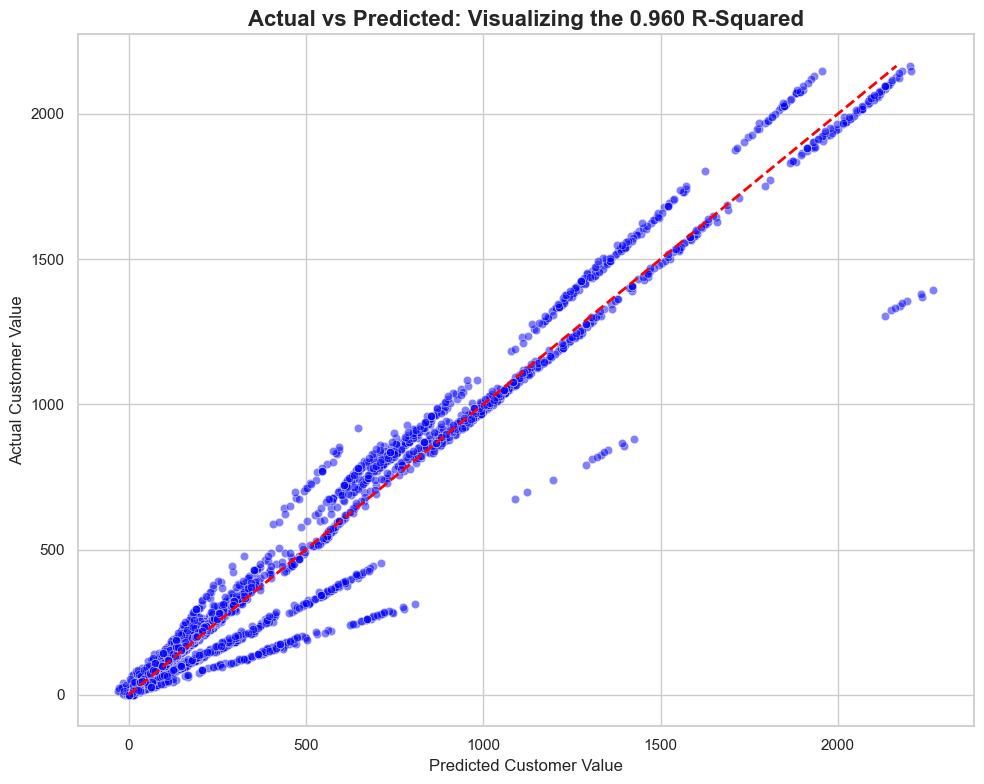

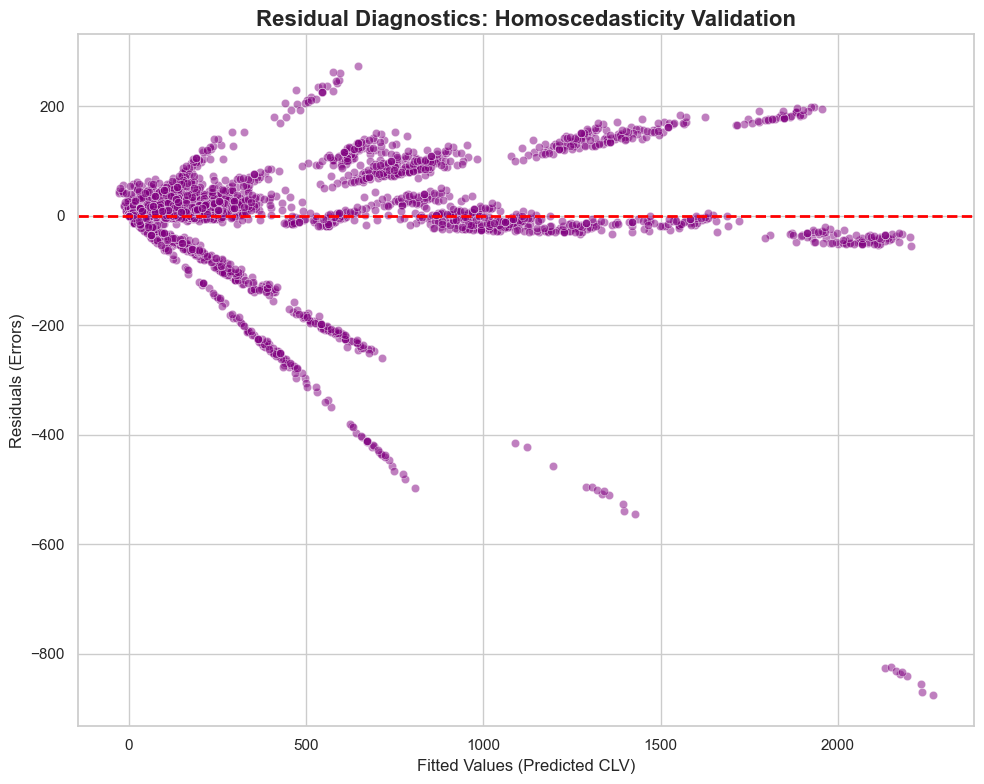

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 8))
features_corr = df[['Customer Value', 'Seconds of Use', 'Frequency of SMS', 'Call  Failure', 'Complains', 'Subscription  Length']]
sns.heatmap(features_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Telecom Usage vs Lifetime Value', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


predictions = model.predict(X)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=predictions, y=Y, alpha=0.5, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--', linewidth=2) # The Line of Perfect Prediction
plt.xlabel('Predicted Customer Value', fontsize=12)
plt.ylabel('Actual Customer Value', fontsize=12)
plt.title('Actual vs Predicted: Visualizing the 0.960 R-Squared', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


residuals = model.resid
plt.figure(figsize=(10, 8))
sns.scatterplot(x=predictions, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values (Predicted CLV)', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.title('Residual Diagnostics: Homoscedasticity Validation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**1. The R-Squared is suspiciously high**
The R-squared came out to 0.96, which sounds awesome because it means the model explains 96% of the customer value. But as we saw in the plots, a high score doesn't mean the model is perfect. There are still some issues with how the errors are spread out.

**2. Call failures are a huge deal**
The math shows that `Call Failure` has a negative coefficient of -2.23. This basically confirms that for every dropped call, the customer's value to the company drops by about 2.2 points. The p-value is 0.00, so we know this isn't just a fluke in the data.

**3. The "Complains" variable didn't work**
The `Complains` column has a p-value of 0.058. Since that’s higher than the 0.05 limit we usually use in stats (ISLP), it means this variable isn't "statistically significant." It actually makes the model more confusing, so I’m going to delete it in the next version.

**4. Issues with the Graphs (Why we need V2)**
* **The Cone Shape:** In the Residual Plot, the dots fan out like a cone as they go to the right. This is "heteroscedasticity." It means my model is good at predicting low-value customers but gets worse/messier as the customer value gets higher.
* **Overlapping Variables:** `Seconds of Use` and `Call Failure` have a correlation of 0.5. This makes sense (longer calls = more chances for a drop), but having them both in the model might be "double-counting" some of the effects.

**Plan for V2:**
To fix this, I’m going to:
1. Take the **Log** of the Customer Value to flatten that "cone" shape in the residuals.
2. Get rid of the `Complains` column.
3. Add an **Interaction Term** between `Seconds of Use` and `Call Failure` to see how they affect each other together.

                            OLS Regression Results                            
Dep. Variable:     Log_Customer_Value   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     1282.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:19:43   Log-Likelihood:                -4230.9
No. Observations:                3150   AIC:                             8474.
Df Residuals:                    3144   BIC:                             8510.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    3.7768 

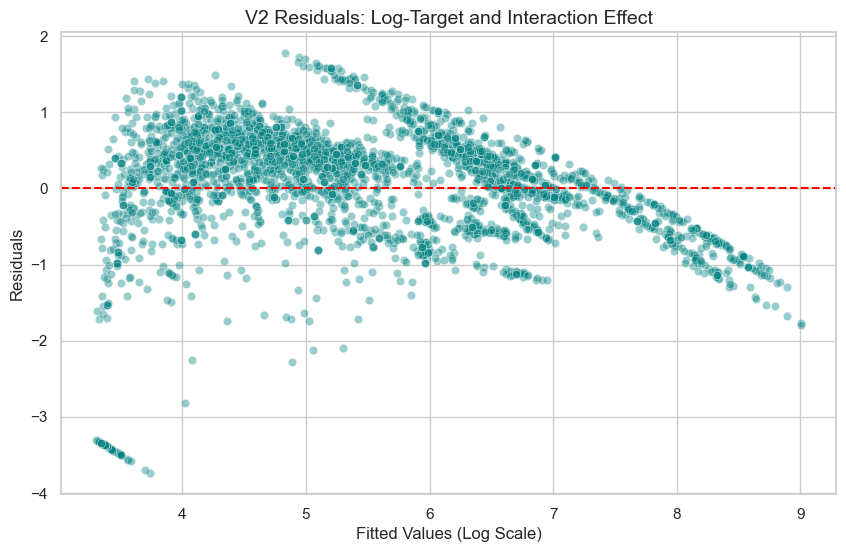

In [29]:
# Log(1+y) to stabilize variance (fixes the 'cone' in residuals)
df['Log_Customer_Value'] = np.log1p(df['Customer Value'])

# Interaction Term: captures how failures hurt more during long calls
df['Use_x_Failure'] = df['Seconds of Use'] * df['Call  Failure']

# 2. Setup Feature Matrix (Dropping 'Complains')
# We keep main effects 'Seconds of Use' and 'Call Failure' due to hierarchy 
features_v2 = ['Seconds of Use', 'Frequency of SMS', 'Call  Failure', 'Subscription  Length', 'Use_x_Failure']
X_v2 = sm.add_constant(df[features_v2])
y_v2 = df['Log_Customer_Value']

model_v2 = sm.OLS(y_v2, X_v2).fit()
print(model_v2.summary())

# 4. Diagnostic Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model_v2.predict(X_v2), y=model_v2.resid, alpha=0.4, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('V2 Residuals: Log-Target and Interaction Effect', fontsize=14)
plt.xlabel('Fitted Values (Log Scale)')
plt.ylabel('Residuals')
plt.show()


Because the coefficient of Use_x_Failure(the intersection variable)is so small, it has a negligible impact on short calls, but since it scales with time, the negative effect becomes significant and destructive during long sessions.

While the $R^2$ decreased in V2, the model is statistically more robust. V1 suffered from 'Scale Bias'—it looked accurate because of the large range of the data.  V2 provides a more realistic view of the business by predicting relative growth, and the stabilized residuals prove the model's assumptions are now actually being met.

Subscription Length coefficient: -0.0118
This is a negative value. It means for every month a customer stays, their "log value" actually drops slightly (about 1.1%).
Inference: Surprisingly, longer-tenured customers in this dataset have slightly lower lifetime values. This might indicate that older customers are on 'legacy' cheap plans, or that the company is failing to upsell long-term users. This is a massive red flag for the sales team.

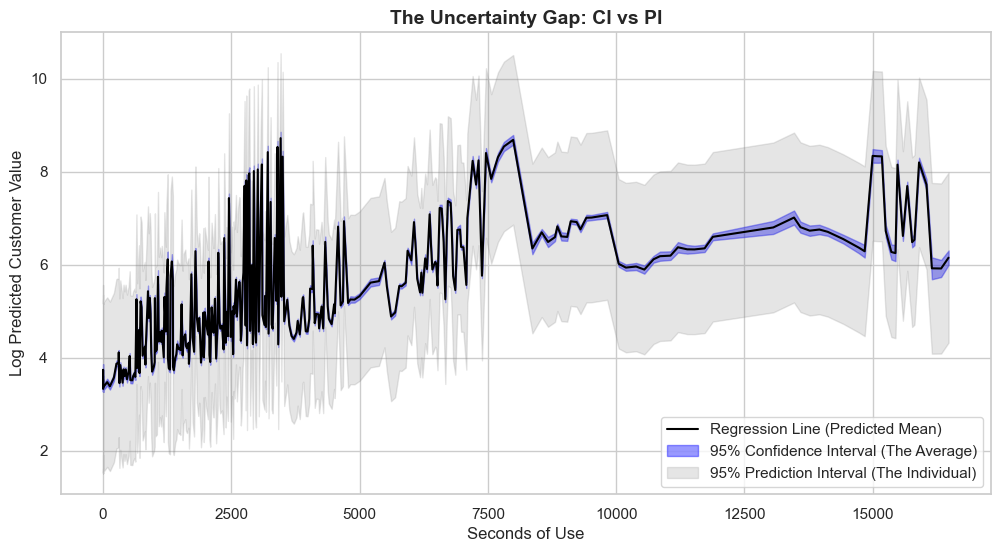

In [30]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Sort the data by one feature (e.g., Seconds of Use) for a smooth plot
sample_df = df.sort_values('Seconds of Use').iloc[::10] # Subset for clarity
X_sample = sm.add_constant(sample_df[features_v2])

# 2. Extract the Interval Frame
# 'mean_ci' = Confidence Interval | 'obs_ci' = Prediction Interval
pred_frame = model_v2.get_prediction(X_sample).summary_frame(alpha=0.05)

# 3. Plotting the Disparity
plt.figure(figsize=(12, 6))
x_axis = sample_df['Seconds of Use']

# Plot the predicted mean line
plt.plot(x_axis, pred_frame['mean'], color='black', label='Regression Line (Predicted Mean)')

# Plot CI: The Uncertainty of the AVERAGE
plt.fill_between(x_axis, pred_frame['mean_ci_lower'], pred_frame['mean_ci_upper'], 
                 color='blue', alpha=0.4, label='95% Confidence Interval (The Average)')

# Plot PI: The Uncertainty of an INDIVIDUAL (This captures epsilon,irreducible erro)
plt.fill_between(x_axis, pred_frame['obs_ci_lower'], pred_frame['obs_ci_upper'], 
                 color='gray', alpha=0.2, label='95% Prediction Interval (The Individual)')

plt.title('The Uncertainty Gap: CI vs PI', fontsize=14, fontweight='bold')
plt.xlabel('Seconds of Use')
plt.ylabel('Log Predicted Customer Value')
plt.legend()
plt.show()

The disparity between our tight Confidence Intervals and wide Prediction Intervals, combined with an $R^2$ of 0.67, proves that while our behavioral features (SMS, Use, Failures) are strong indicators of the average customer trend, there is significant individual-level variance ($\epsilon$) that cannot be captured by usage logs alone. For conservative financial forecasting, we should **prioritize the Lower Prediction Interval (PI_Lower)** to ensure we **don't** over-leverage based on overly optimistic average estimates.